# Introducción

Este es el primer notebook de una serie de tutoriales interactivos para aprender y poner en práctica diferentes técnicas de optimización en Machine Learning aplicado a la resolución de problemas combinatorios. Se trabajará mediante el uso de modelos Transformer, cuyo mecanismo de atención permite modelar convenientemente las relaciones entre los diferentes elementos de un problema. Asimismo, el *framework* se centra en la resolución del Problema del Vendedor Viajero (TSP), que busca encontrar la ruta más corta que existe para un conjunto de puntos o ubicaciones en el espacio.

Cada guía interactiva está estructurada en base a la siguiente secuencia de pasos:

1. **Generación de instancias**: Generación de los problemas base que vamos a utilizar para generar los datos para posteriormente entrenar el modelo. Las instancias se componen por un conjunto de $n$ puntos en el espacio representados mediante sus coordenadas $(x, y)$. En este paso, todavía **no** hemos aplicado ningún algoritmo de resolución.

2. **Generación de datos**: Aplicación de un algoritmo para resolver las instancias generadas previamente. Como en su mayoría trabajaremos mediante **aprendizaje supervisado**, el objetivo de este paso se traduce a generar los ejemplos (entradas y salidas) con los cuales entrenaremos el modelo. Debido a esto, también es necesario determinar cuál será el formato de la entrada/salida esperadas del modelo (¿un vector de coordenadas? ¿matriz de distancia?).

3. **Definición de la arquitectura**: Consiste en definir la estructura de la red neuronal que utilizaremos para resolver el problema. Es decir, toda la secuencia de capas por las cuales se da el flujo de los datos desde que ingresa a la red neuronal (entrada) hasta que sale (valor predicho).

4. **Entrenamiento de la red**: Consiste en definir el mecanismo mediante el cual vamos a alimentar a la red neuronal con los ejemplos previamente generados. Normalmente aplicaremos aprendizaje supervisado, sin embargo, esto requiere definir una serie de parámetros de configuración o hiperparámetros (tasa de aprendizaje, número de épocas, etc.) que determinarán el modo en que aprende la red.

5. **Validación de la red**: Procedimiento mediante el cual vamos a verificar si la red realmente aprendió. El modelo no puede resolver un problema por sí solo, sino que necesita estar integrado en un algoritmo (agente) que lo utilice paso a paso hasta generar una solución final.

A continuación, exploraremos más en detalle cada fase de esta metodología.

## 1. Generación de instancias

Las instancias corresponden a un conjunto de $n$ puntos o ciudades generados de manera aleatoria y representados mediante sus coordenadas $(x, y)$.

Para| generar instancias aleatorias del problema utilizaremos la función `generate_instances`, que recibe los siguientes parámetros:

- `filename`: Nombre del archivo de salida.
- `instance_count`: Cantidad de instancias a generar.
- `cities`: Número de ciudades de las instancias (20, 50, 100, etc.)
- `seed`: Semilla de generación. Una misma semilla siempre genera las mismas instancias.

El archivo de salida quedará almacenado dentro de la carpeta `instances` en formato codificado `pkl` para optimización de espacio.

In [28]:
from instances.instances import generate_instances

# Generamos 1000 instancias de 50 ciudades con una semilla fija para reproducibilidad
instances = generate_instances(
    filename="TSP50.pkl", 
    instance_count=1000, 
    cities=50, 
    seed=42
)
print(f"Se han generado {len(instances)} instancias correctamente en 'instances/TSP50.pkl'.")

Se han generado 1000 instancias correctamente en 'instances/TSP50.pkl'.


# 2. Generación de datos

Una vez generadas las instancias, debemos resolverlas para generar datos a partir de ellas. Un dato se compone por una entrada $x$ y una salida $y$.

### Entrada del problema

Resulta **fundamental** definir cómo vamos a representar la entrada del problema. Para ello, se recomienda responder en orden las siguientes preguntas:

#### 1. ¿Cómo se representa una **instancia** del problema?

En cualquier problema combinatorio, inicialmente tendremos una o varias secuencias de elementos. En el caso del TSP, tenemos ciudades. Para el problema de la mochila, tenemos objetos. Para problemas de empaquetamiento, normalmente tendremos cajas o bloques.

La clave está en determinar qué diferencia a un elemento de cualquier otro en la secuencia. Los componentes que caracterizan un determinado elemento en particular los llamaremos ***features*** o características.

- Para el TSP, cada ciudad se representa mediante sus coordenadas $(x, y)$.
- Para el problema de la mochila, cada objeto se representa mediante su valor $v$ y su peso $w$.
- Para problemas de empaquetamiento, cada caja se representa mediante sus dimensiones $(l, w, h)$.

Con esto, cada secuencia debe representarse como un vector o lista de elementos, donde cada elemento se representa mediante sus características:

$$\begin{bmatrix} x_1 & y_1 \\ x_2 & y_2 \\ x_3 & y_3 \\ \vdots & \vdots \\ x_n & y_n \end{bmatrix}$$

#### 2. ¿Cómo se representa un **estado** del problema?

Cada problema combinatorio se puede resolver mediante una serie de pasos constructivos. En el TSP, visitamos cada ciudad en un orden particular. En el problema de la mochila, vamos añadiendo objetos. En los problems de empaquetamiento, añadimos cajas a un contenedor.

Aquí, la clave es identificar qué hace distinto un estado particular del problema de otro estado cualquiera. Es decir, las ciudades que ya hemos visitado, los objetos que ya hemos añadido, las variables que ya hemos asignado. Generalmente, esto es información suficiente para distinguir entre estados.

En el caso del TSP, basta con incorporar una lista de ciudades visitadas (*tour* actual). Aquí no es necesario integrar las coordenadas $(x, y)$, ya que sería información redundante que ya consideramos anteriormente. Simplemente podemos utilizar los índices de cada ciudad. Tampoco es necesario una lista de las ciudades **no** visitadas, puesto que puede deducirse fácilmente a partir de las visitadas.

#### Codificación

Este *framework* utiliza **adaptadores** para codificar la entrada y salida del problema. Para la entrada, un adaptador básico se vería de la siguiente manera:

In [30]:
from data.adapters.input.input_adapter import InputAdapter
from TSP import TSPState
import numpy as np

class DistanceInputAdapter(InputAdapter):
    """
    Adaptador básico que extrae las coordenadas de la instancia 
    y la lista de ciudades visitadas del estado actual.
    """
    def __init__(self):
        super().__init__({
            "coords": np.float32,
            "visited": np.int32,
        })

    def input_2_vec(self, state: TSPState):
        """
        Transforma el estado actual en tensores de NumPy.
        """
        # Extraer coordenadas (N, 2)
        coords = np.array(state.instance.city_locations, dtype=np.float32)
        
        # Extraer ciudades visitadas (tour actual). 
        # Forzamos dtype por si el tour está vacío en el estado inicial.
        visited = np.array(state.tour, dtype=np.int32)

        return coords, visited

La función `input_2_vec` traduce un estado actual del problema (`TSPState`) a componentes matemáticos (vectores, matrices o escalares) para que puedan ser procesados por el modelo. 

#### Adaptación a diferentes tamaños de entrada

El problema con el adaptador anterior es que el tamaño de los vectores queda determinado por la cantidad de ciudades que componen la instancia. Normalmente, vamos a querer entrenar con diferentes tamaños de instancia (10, 50 o hasta 100 ciudades). A la hora de armar nuestra "colección" de datos o *dataset*, todos los datos quedarán almacenados en una gran secuencia, donde todos los elementos deben tener necesariamente el **mismo tamaño**, y si el tamaño de cada dato está determinado por el número de ciudades, entonces tendremos un problema.

La manera de solucionar esto es mediante las técnicas de ***padding*** y **enmascaramiento**. La técnica de *padding* la aplicaremos aquí, directamente en el adaptador. El enmascaramiento lo aplicaremos posteriormente en la arquitectura del modelo.

El *padding* consiste en incrementar artificialmente el tamaño de los vectores con posiciones de relleno (normalmente valores de -1 o 0) para que todos los elementos queden del mismo tamaño (uniforme). A la hora de entrenar el modelo, estas posiciones simplemente serán ignoradas y no tendrán ningún efecto en el entrenamiento. La cantidad de *padding* que apliquemos estará determinada por el tamaño máximo de instancia con la cual vayamos a entrenar. Si entrenamos con 10, 50 y 100 ciudades, el tamaño máximo es 100 y todos los vectores deberán quedar de este tamaño.

Para que posteriormente el modelo sepa exactamente la cantidad de ciudades válidas y pueda ignorar correctamente las posiciones de *padding*, añadiremos la variable `num_cities`.

In [31]:
from data.adapters.input.input_adapter import InputAdapter
from TSP import TSPState
import numpy as np

class DefaultInputAdapter(InputAdapter):
    """
    Adaptador con soporte para padding, permitiendo procesar instancias 
    de hasta `max_cities` ciudades en un mismo batch.
    """
    def __init__(self, max_cities=100):
        super().__init__({
            "coords": np.float32,
            "visited": np.int32,
            "num_cities": np.int32
        }, max_cities)

    def input_2_vec(self, state: TSPState):
        coords = np.array(state.instance.city_locations, dtype=np.float32)
        num_cities_actual = len(coords)
        
        # Padding para coordenadas: rellenamos con 0.0 al final si faltan ciudades
        pad_len = self.max_cities - num_cities_actual
        if pad_len > 0:
            coords = np.pad(coords, ((0, pad_len), (0, 0)), mode='constant', constant_values=0.0)
            
        # Padding para ciudades visitadas: rellenamos con -1 las posiciones vacías
        tour_array = np.array(state.tour, dtype=np.int32)
        visited = np.pad(tour_array, (0, self.max_cities - len(tour_array)), mode='constant', constant_values=-1)

        return coords, visited, state.instance.num_cities

#### Salida del problema

La salida del problema estará determinada según aquello que buscamos predecir. Normalmente, tenemos dos opciones:

- Para problemas de **regresión**, buscamos predecir un **valor** (cuando buscamos maximizar algo) o **costo** (cuando buscamos minimizar): ¿cuál es el costo óptimo de una instancia del TSP? ¿cuál es el valor óptimo que puedo alcanzar añadiendo objetos a la mochila (en el caso de KP)?

- Para problemas de **clasificación**, buscamos predecir una **probabilidad** para cada elemento de una secuencia: ¿cuál es la probabilidad de que cada ciudad no visitada sea la siguiente en el tour? ¿cuál es la probabilidad de añadir cada objeto a la mochila en el siguiente paso? Aquí normalmente usamos vectores *one-hot* con un 1 en la acción elegida por el algoritmo de resolución, concentrando el 100% de probabilidad.

También podemos utilizar adaptadores para modelar la salida. En el siguiente adaptador, dado un estado y la siguiente ciudad a visitar (según el algoritmo de resolución), utilizaremos un vector *one-hot* para representar la salida.

In [32]:
from data.adapters.output.output_adapter import OutputAdapter
from TSP import TSPState
import numpy as np

class DefaultOutputAdapter(OutputAdapter):
    """
    Adaptador de salida para clasificación. Genera un vector one-hot 
    apuntando a la siguiente ciudad óptima a visitar.
    """
    def __init__(self, max_cities=100):
        super().__init__({
            "Y": np.int32
        }, max_cities)

    def output_2_vec(self, state: TSPState, best_city: int, final_cost: float):
        # final_cost se ignora en clasificación, se usaría si el modelo fuera un Critic (regresión)
        Y = np.zeros(self.max_cities, dtype=np.int32)
        Y[best_city] = 1

        return Y

#### Algoritmo de generación

Finalmente, para generar nuestro dataset consolidado a partir de nuestras instancias y adaptadores, utilizaremos la función `generate_train_data`, la cual recibe:

- `instance_file`: Nombre del archivo de instancias.
- `data_filename`: Nombre del archivo del dataset de salida.
- `input_adapter_config`: Configuración del adaptador de entrada en formato (clase del adaptador, *parámetros de inicialización)
- `output_adapter_config`: Configuración del adaptador de salida en formato (clase del adaptador, *parámetros de inicialización)
- `num_workers`: Procesos a correr en paralelo.
- `size`: Tamaño máximo del dataset a generar.

Esta función utiliza internamente la librería **OR-Tools** para resolver las instancias, un *solver* altamente optimizado y que entrega soluciones casi óptimas en un tiempo eficiente. Los datasets quedan almacenados en la carpeta `data` en formato `h5` para optimización de memoria.

In [34]:
from data.generation import generate_train_data
from data.adapters.input.default import DefaultInputAdapter
from data.adapters.output.default import DefaultOutputAdapter

# Configuración de los adaptadores con max_cities = 50
input_config = (DefaultInputAdapter, 50)
output_config = (DefaultOutputAdapter, 50)

# Generación del dataset usando OR-Tools como oráculo
generate_train_data(
    instance_file="cost.pkl", 
    data_filename="train_data.h5", 
    input_adapter_config=input_config, 
    output_adapter_config=output_config,
    num_workers=None,
    size=5000
)

Datos guardados en: /home/oscar/Escritorio/TSP-Framework/data/train_data.h5 (Tamaño: 5000)


### 3. Definición de la arquitectura

El siguiente paso consiste en definir la arquitectura del modelo. Aquí debemos tomar decisiones sobre cómo procesar los datos de entrada de manera inteligente, para que finalmente el modelo tenga la capacidad de aprender a predecir la salida esperada.

Utilizaremos redes ***Transformer*** para resolver nuestro problema. Estos modelos se componen de dos partes principales:

1. Un ***encoder*** encargado de procesar la información de la **instancia** del problema. En el caso del TSP, esto corresponde al grafo de ciudades.
2. Un ***decoder*** encargado de tomar la siguiente decisión a partir del estado actual, basándose en la información ya procesada del problema (*encoder*).

Todas las arquitecturas poseen una serie de parámetros configurables (hiperparámetros). Diferentes configuraciones de parámetros darán diferentes resultados durante el entrenamiento. Determinar la mejor configuración es una tarea no trivial, y normalmente requiere varios experimentos de ensayo y error o algoritmos/librerías especializadas en **optimización de hiperparámetros**.

Para una arquitectura típica, algunos hiperparámetros son los siguientes:

- `embed_dim`: Dimensión de los embeddings (vectores latentes) utilizados para representar cada ciudad dentro del modelo. Es el tamaño del "vocabulario" interno de la red para describir un nodo.

- `num_heads`: Número de "cabezas" en el mecanismo de atención (Multi-Head Attention). Permite que el modelo preste atención a diferentes tipos de relaciones (espaciales, de distancia, de orden) entre las ciudades simultáneamente.

- `num_encoder_layers`: Cantidad de capas de atención apiladas en el encoder. Más capas permiten al modelo capturar patrones más complejos, pero aumentan el tiempo de entrenamiento y el riesgo de sobreajuste.

- `dropout_rate`: Fracción de conexiones neuronales que se "apagan" aleatoriamente durante el entrenamiento. Es una técnica de regularización para evitar el sobreajuste (overfitting).

En este primer *notebook* elegiremos la arquitectura estándar en la literatura, basada en mecanismos tipo *glimpse*. Por ahora, no tenemos que preocuparnos por la implementación. Los componentes arquitectónicos serán explicados en *notebooks* futuros.

In [5]:
from models.glimpse import TSPTransformer

# Parámetros del modelo
input_dim = 2
embed_dim = 64
num_heads = 4
num_encoder_layers = 2
num_glimpses = 2
dropout = 0.1

# Crear modelo
model = TSPTransformer(
    input_dim=input_dim,
    embed_dim=embed_dim,
    num_heads=num_heads,
    num_encoder_layers=num_encoder_layers,
    num_glimpses=num_glimpses,
    dropout_rate=dropout
)
# En este punto, 'model' es una red inicializada con pesos aleatorios, lista para aprender.

## 4. Entrenamiento de la red

Para el entrenamiento de la red, el primer paso es determinar los subconjuntos de datos que serán utilizados para el entrenamiento. Es importante hacer la distinción acerca de los diferentes conjuntos de datos que se utilizan para entrenar y evaluar el modelo:

1. **Conjunto de entrenamiento**: datos que se utilizarán directamente para la optimización de los pesos del modelo (aprendizaje).

2. **Conjunto de validación**: datos que se utilizarán para validar el desempeño del modelo **durante** el entrenamiento. La gracia es que el modelo nunca aprende directamente de este dataset, por lo cual el desempeño que obtenga es mucho más representativo de su aprendizaje real (¿está memorizando los datos, o logró capturar la "esencia" del problema?).

3. **Conjunto de prueba**: datos que se utilizan para validar el modelo **después** del entrenamiento. Corresponden a instancias o datos nunca antes vistos por el modelo, por lo que su propósito es realizar una evaluación totalmente objetiva de su desempeño real.

Para esta fase nos interesan los primeros dos conjuntos. Para generarlos, utilizamos el dataset generado anteriormente y realizamos un ***split*** o división que determinará la proporción de datos que vamos a utilizar para entrenamiento y para validación. Proporciones comunes son `80/20` (80% para entrenamiento y 20% para validación) o `70/30` (más conservador).

In [6]:
from data.preprocessing import load_dataset, split_dataset

# Como son 5000 datos, usaremos 4000 para entrenamiento y 1000 para validación (80/20)
train_file, val_file = split_dataset("train_data.h5", 4000)

train_dataset = load_dataset(train_file)
val_dataset = load_dataset(val_file)

Cargando dataset original: /home/oscar/Escritorio/TSP-Framework/data/train_data.h5
Guardando Train puro (4000 muestras) en: train_data_train.h5
Guardando Val puro (1000 muestras) en: train_data_val.h5
Dataset train_data_train.h5 cargado con 4000 muestras.
Dataset train_data_val.h5 cargado con 1000 muestras.


Otro paso importante es determinar la función de pérdida o loss function que será utilizada para la optimización del modelo. Para problemas de clasificación, lo común es utilizar **Cross Entropy Loss**, definida como:

$$\text{Loss}=-\sum _{c=1}^{C}y_{c}\log (p_{c})$$

donde $C$ es el número total de clases (en este caso, las ciudades disponibles a elegir), $y_c$ es un indicador binario que vale 1 si la clase $c$ es la ciudad correcta (según nuestro oráculo) y 0 para el resto, y $p_c$ es la probabilidad predicha por el modelo de que la ciudad $c$ sea la óptima. Esta función penaliza fuertemente al modelo si asigna una probabilidad baja a la ciudad correcta.

Para monitorear el desempeño en el conjunto de validación, utilizaremos la métrica de **Accuracy** (exactitud). Esta métrica calcula simplemente el porcentaje total de veces que el modelo predijo correctamente la siguiente ciudad a visitar en comparación con las decisiones tomadas por el solver experto.

Adicionalmente, debemos definir una serie de hiperparámetros propios del entrenamiento. Los básicos son:

- Número de épocas (`epochs`): Cantidad de épocas de entrenamiento. Cada época corresponde a una iteración sobre todos los datos disponibles.

- Tamaño del lote (`batch_size`): Cantidad de datos que se van a procesar por cada actualización (*backward*) del modelo. Un `batch_size` más alto implica menos actualizaciones, pero más representativas de la dirección real de aprendizaje.

- Tasa de aprendizaje (`lr_config`): Configuración de la tasa de aprendizaje. Determina la velocidad con la que aprende el modelo. Un valor muy alto hace que el modelo dé pasos demasiado grandes, lo que impide que finalmente converja. Por el contrario, un valor muy pequeño ralentiza el aprendizaje e impide que el modelo pueda escapar de óptimos locales.

Para entrenar el modelo, llamaremos a la función sl_train, la cual recibe como parámetros:

- `model`: La instancia de la red neuronal que definimos previamente.

- `epochs`: Número de épocas que durará el entrenamiento.

- `train_set` y `val_set`: Los conjuntos de datos cargados para entrenar y evaluar, respectivamente.

- `batch_size`: La cantidad de ejemplos procesados en cada lote.

- `lr_config`: Un objeto con la configuración de la tasa de aprendizaje.

- `loss_fn`: La función de pérdida a optimizar (Cross Entropy).

- `metrics`: Una lista con las métricas adicionales que queremos calcular por época para monitorear el desempeño (Accuracy).

- `metrics_filename`: Nombre del archivo donde se guardará el registro histórico del entrenamiento.

In [7]:
from training.sl import sl_train, LRConfig
from training.metrics import CrossEntropyLoss, Accuracy

model = sl_train(
    model=model,
    epochs=10,
    train_set=train_dataset,
    val_set=val_dataset,
    batch_size=64,
    lr_config=LRConfig(value=1e-4),
    loss_fn=CrossEntropyLoss(),
    metrics=[Accuracy()],
    metrics_filename="metrics.txt"
)

** Usando dispositivo: cpu

Epoch 1/10
    Train CrossEntropy: 2.8310 | Val CrossEntropy: 1.7664
    Accuracy: 56.10%
Epoch 2/10
    Train CrossEntropy: 1.6153 | Val CrossEntropy: 1.3310
    Accuracy: 65.60%
Epoch 3/10
    Train CrossEntropy: 1.3011 | Val CrossEntropy: 0.9852
    Accuracy: 79.40%
Epoch 4/10
    Train CrossEntropy: 1.0297 | Val CrossEntropy: 0.8625
    Accuracy: 78.50%
Epoch 5/10
    Train CrossEntropy: 0.9167 | Val CrossEntropy: 0.7936
    Accuracy: 80.00%
Epoch 6/10
    Train CrossEntropy: 0.8513 | Val CrossEntropy: 0.7366
    Accuracy: 80.50%
Epoch 7/10
    Train CrossEntropy: 0.8215 | Val CrossEntropy: 0.7293
    Accuracy: 80.70%
Epoch 8/10
    Train CrossEntropy: 0.7875 | Val CrossEntropy: 0.6922
    Accuracy: 81.10%
Epoch 9/10
    Train CrossEntropy: 0.7627 | Val CrossEntropy: 0.6740
    Accuracy: 81.20%
Epoch 10/10
    Train CrossEntropy: 0.7490 | Val CrossEntropy: 0.6463
    Accuracy: 82.40%

** Historial de entrenamiento guardado en: /home/oscar/Escritorio/TSP-

Finalmente, guardamos el modelo entrenado mediante la función `save_model`. Esta almacenará los pesos del modelo y sus hiperparámetros dentro de la carpeta `models`, para posteriormente cargarlos y utilizarlos para su validación.

In [11]:
from training.sl import save_model
save_model(model, model_name="model_glimpse")

** Modelo guardado en /home/oscar/Escritorio/TSP-Framework/models/model_glimpse.pth


# 5. Validación del modelo

El objetivo de esta fase es evaluar el desempeño del modelo sobre instancias no vistas. En otras palabras, es la etapa que nos dirá si el modelo logró aprender más allá de las instancias de entrenamiento (es capaz de lograr un buen desempeño frente a cualquier instancia) o si simplemente memorizó los patrones que encontró durante su entrenamiento.

Para ello, lo primero que haremos será cargar el modelo anteriormente entrenado mediante la función `load_model`.

In [1]:
from training.sl import load_model
from models.glimpse import TSPTransformer

# Cargamos los pesos del modelo que acabamos de entrenar
model = load_model(TSPTransformer, model_name="model_glimpse")

Es importante recordar que el modelo, por sí solo, únicamente genera predicciones (probabilidades). Para resolver el problema completo, necesitamos un algoritmo que utilice estas predicciones para construir una solución paso a paso. Para esto utilizaremos `ModelSolver`, un agente o *solver* constructivo que, en cada paso de la resolución, consulta al modelo y toma la decisión de visitar la ciudad que tenga la mayor probabilidad asignada. Este proceso se repite hasta completar el recorrido.

Para saber qué tan buenas son las rutas construidas por el modelo, necesitamos compararlas contra un estándar experto. Utilizaremos nuevamente **OR-Tools** como nuestro oráculo.

La métrica principal que utilizaremos para esta evaluación es el **Gap de Optimalidad** (*Optimality Gap*). Esta métrica calcula la diferencia porcentual entre el costo de la solución generada por el modelo y el costo de la solución casi óptima encontrada por OR-Tools. Un gap del 0% significa que el modelo igualó al oráculo; un gap del 5% significa que las rutas del modelo son, en promedio, un 5% más largas.

A continuación, ejecutaremos ambos *solvers* sobre un conjunto de instancias de prueba (*benchmark*) y calcularemos el desempeño final.

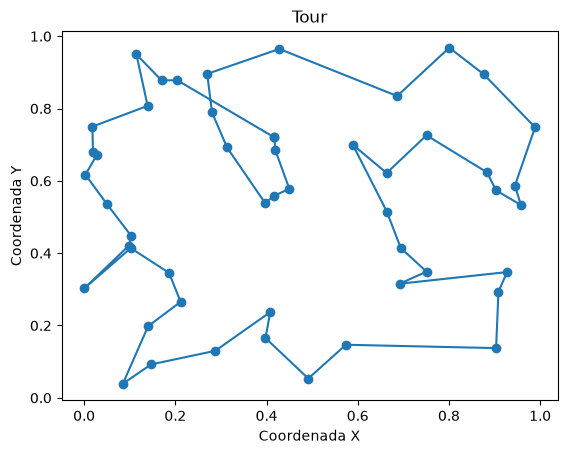

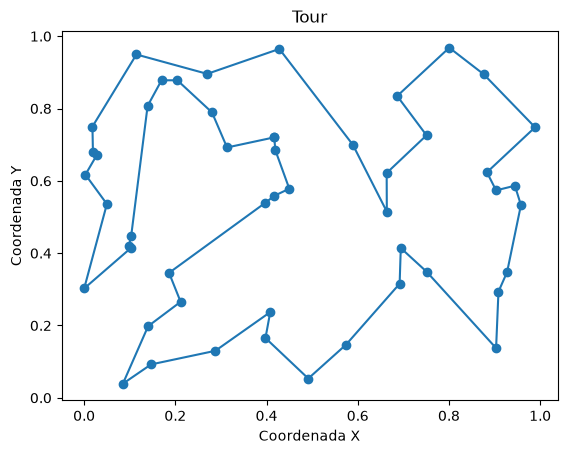

Costo promedio Modelo: 6.40
Costo promedio OR-Tools: 5.82
Gap de optimalidad: 10.02%


In [2]:
from solvers.model import ModelSolver
from solvers.ortools import ORToolsSolver
from solvers.eval import calculate_gap
from data.adapters.input.default import DefaultInputAdapter
import numpy as np

input_adapter = DefaultInputAdapter(max_cities=50)
model_solver = ModelSolver(model, input_adapter)
ortools_solver = ORToolsSolver()

# Resolvemos un conjunto de prueba nunca antes visto por el modelo
model_sols = model_solver.solve("benchmarks/B50.pkl")
ort_sols = ortools_solver.solve("benchmarks/B50.pkl")

# Generamos una representación visual en 2D comparando la ruta del modelo vs OR-Tools
# (Útil para analizar visualmente los cruces o ineficiencias del modelo)
model_sols[0].plot()
ort_sols[0].plot()

# Calculamos e imprimimos las métricas de validación
model_avg = np.mean([model_sol.get_total_cost() for model_sol in model_sols])
ort_avg = np.mean([ort_sol.get_total_cost() for ort_sol in ort_sols])
gap_promedio = calculate_gap(model_sols, ort_sols)

print(f"Costo promedio Modelo: {model_avg:.2f}")
print(f"Costo promedio OR-Tools: {ort_avg:.2f}")
print(f"Gap de optimalidad: {gap_promedio:.2f}%")